# NLP Foundations Workshop: Vector Space Proximity

### Introduction to Vector Space Proximity

A large majority of the data on the Internet is **unstructured**, for example: social media posts, emails, images, videos and audio files.

If we want to **persist** all these media in a database, we may add **metadata** about them, such as file type or creation date timestamp, or we could  **tag** each file, or parts of it, so they are easy to search for. This is because it would be very difficult to identify them based on their low-level (byte) representations.

But, what if we want to make the process fully automated (i.e., remove the need to manually add features, like tags, to each media item)? We need another way to represent the semantics of digital media.

That is the reason why in **Information Retrieval (IR)** and **Natural Language Processing (NLP)**, we often represent documents and queries as **vectors** in a **high-dimensional space**, where:

* Each **dimension** corresponds to a **unique term** in the vocabulary.
* A **document** is represented by a **point** or a **vector** in the space.
* A **vector** is a list of weights (e.g., term frequencies, TF-IDF values) that describe the presence or importance of terms in a document or query.

---

#### Example 1: "Rich" and "Poor" Axes

![Vector Space Example: "Rich" and "Poor" Axes"](Fig1_CartesianVectorSpace.png)

Suppose our vocabulary only has two terms:

* `"rich"`
* `"poor"`

These two terms define a **2D Cartesian space**:

* The **x-axis** corresponds to the term **"rich"**.
* The **y-axis** corresponds to the term **"poor"**.

Each document is represented as a vector in this space:

* A document with many occurrences of “poor” and none of “rich” lies near the **y-axis**.
* A document that mentions both “rich” and “poor” lies in the **first quadrant**.
* A document with only “rich” is aligned along the **x-axis**.

The **query vector** $q = \{\text{"rich"}, \text{"poor"}\}$ points in the direction of interest for the search engine.

###  Euclidean Distance and Its Limitations

One might assume we can measure similarity using **Euclidean distance**:

$$
\text{Euclidean}( \vec{q}, \vec{d} ) = \sqrt{ \sum_{i=1}^{n} (q_i - d_i)^2 }
$$

However, this has problems in practice:

* If document $d_2$ contains more occurrences of both “rich” and “poor” than the query, its vector will have a **longer length**.
* As seen in the diagram, even though $d_2$ has strong content overlap with the query $q$, it may still be **further away** in Euclidean terms than unrelated documents like $d_3$.
* This happens because **magnitude dominates**, not direction.

###  Angle as Similarity → Cosine Similarity

To solve this, we focus on **vector direction**, not length. We measure **angle** between the document and query vectors using **Cosine Similarity**:

$$
\cos(\vec{q}, \vec{d}) = \frac{ \vec{q} \cdot \vec{d} }{ \|\vec{q}\| \cdot \|\vec{d}\| }
= \frac{ \sum_{i=1}^{n} q_i \cdot d_i }{ \sqrt{ \sum_{i=1}^{n} q_i^2 } \cdot \sqrt{ \sum_{i=1}^{n} d_i^2 } }
$$

* This gives us a similarity score from **0 (orthogonal)** to **1 (identical direction)**.
* Longer documents that are semantically aligned still get **high similarity**.

###  Why Cosine Similarity Works Better

* **Angle** captures **semantic alignment**.
* It is **not affected** by document length or repetition.
* Example: duplicating document $d$ to make $d'$ will increase Euclidean distance — but **cosine similarity remains 1**.

Cosine similarity is at the core of:

* **Search ranking**
* **Embedding-based retrieval**
* **LLM scoring and attention mechanisms**

Sample code:

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Define the documents and the query
documents = [
    "Ranks of starving poets swell",       # d1
    "Rich poor gap grows",                 # d2
    "Record baseball salaries in 2010"     # d3
]

query = ["rich poor"]                     # q

# Create a CountVectorizer to convert text to term frequency vectors



# Separate vectors
doc_matrix =                      # d1, d2, d3
query_vector =                    # q

# Compute cosine similarity
cosine_similarities = 

# Create a DataFrame to show results


# Display the result
df


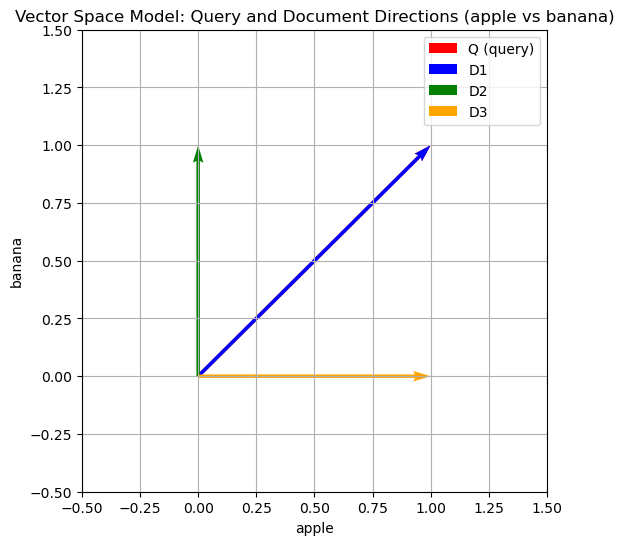

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Define the 2D (apple, banana) projections
vectors = {
    'Q (query)': np.array([1, 1]),
    'D1': np.array([1, 1]),
    'D2': np.array([0, 1]),
    'D3': np.array([1, 0])
}

colors = {'Q (query)': 'red', 'D1': 'blue', 'D2': 'green', 'D3': 'orange'}

plt.figure(figsize=(6,6))
for label, vec in vectors.items():
    plt.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1, color=colors[label], label=label)

# Axes limits and labels
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel('apple')
plt.ylabel('banana')
plt.grid(True)
plt.legend()
plt.title("Vector Space Model: Query and Document Directions (apple vs banana)")
plt.show()


# Extra Challenge: Word Vectors in a Small Corpus

Let's start with a small corpus of just six words, each represented by a vector in 3D space:

```plaintext
CAT     → [ 0.2, -0.4,  0.7]
DOG     → [ 0.6,  0.1,  0.5]
APPLE   → [ 0.8, -0.2, -0.3]
ORANGE  → [ 0.7, -0.1, -0.6]
HAPPY   → [-0.5,  0.9,  0.2]
SAD     → [ 0.4, -0.7, -0.5]
```

Each term is represented by a **vector in 3D space**.

###  Observations

- Words with **similar meanings** tend to have **similar vector representations**.
  - For example, **APPLE** and **ORANGE** are close in vector space, reflecting their semantic similarity.

- Words with **opposite meanings** tend to have **vectors pointing in opposite directions**.
  - For instance, **HAPPY** and **SAD** have contrasting vectors, indicating their opposing emotional tones.

![3D Visualizationof Word Vectors](Fig2_3DVisualizationWordVectors.png)



Vector representations are also called **Embeddings**.

There are several approaaches to how **word embedding methods** generate effective vector representations. 

One of them is **frequency-based embeddings**, word representations that are derived from the frequency of words in a corpus. They are based on the idea that the **importance** or the **significance** of a word can be inferred from **how frequently it occurs in the text**. One such embedding is called **Term Frequency - Inverse Document Frequency** or **TF-IDF**. 

TF-IDF highlights words that are frequent within a specific document but are rare across the entire corpus. For example, in a document about music, it would emphasize words such as **rap**, **disco**, **pop**, **rock**. On the other hand, pronouns would receive a low TF-IDF score.

There are various models for generating word embeddings.

### Word Embeddings with Word2Vec

**Word2Vec** is one of the most influential models for learning **dense vector representations** of words, also known as **embeddings**.

Unlike frequency-based models like TF-IDF, Word2Vec uses a **neural network** to learn word vectors such that **similar words have similar embeddings**.

There are two main architectures:

* **CBOW (Continuous Bag of Words)**: Predicts a word from its context.
* **Skip-gram**: Predicts context words from a target word.

Both approaches rely on the **distributional hypothesis**: words that appear in similar contexts tend to have similar meanings.

### Code Challenge: Learn Word Embeddings Using Word2Vec

####  Your Task:

Write Python code that:

1. Prepares a small corpus of tokenized sentences.
2. Trains a **Word2Vec** model on this corpus using Gensim.
3. Displays the vector representation for a few words.
4. Finds the most similar words to a chosen term.

####  Hints:

* Use `from gensim.models import Word2Vec`
* Tokenize your corpus as a list of word lists (sentences).
* Try: `model.wv['word']`, `model.wv.most_similar('word')`

**Example Questions to Explore:**

* What is the shape of a word vector?
* Which words are closest to "learning", "data", or "model"?
* Can Word2Vec capture analogies (e.g., "king" - "man" + "woman")?

Try it out and see what your model learns! 

####  Solution:

In [ ]:
# Word2Vec Code Challenge
from gensim.models import Word2Vec

# 1. Prepare a small corpus of tokenized sentences
corpus = [
    ['machine', 'learning', 'is', 'fun'],
    ['deep', 'learning', 'models', 'are', 'powerful'],
    ['data', 'science', 'uses', 'models'],
    ['word', 'embeddings', 'capture', 'semantics'],
    ['neural', 'networks', 'learn', 'representations'],
    ['model', 'accuracy', 'depends', 'on', 'data'],
    ['king', 'queen', 'man', 'woman'],
    ['python', 'is', 'popular', 'for', 'data', 'science']
]

# 2. Train a Word2Vec model

# 3. Display vector representations for a few words


# 4. Find most similar words to a chosen term


# 5. Analogy: king - man + woman


# What's Really Going On?
When you train a Word2Vec model:

* Each word becomes a vector of real numbers.
* These vectors live in a multi-dimensional space (in your case, 20D).
* The proximity (closeness) between words in that space reflects similarity of meaning or context.

# Example: Word Vector Breakdown
Here's one word vector you saw:

**Vector for 'learning':**
**[ 5.44e-05, -0.0129, -0.0317, ..., 0.0131 ]**

* This is a 20-dimensional vector: each number is a "coordinate" of the word "learning" in this abstract space.
* We can't visualize 20D, but you can imagine each vector like an arrow pointing to a specific location in space.
* Similar words will have vectors pointing in similar directions.

**Vector for 'king':**
**[-0.02120683  0.03294286 -0.02494869  0.02968171 -0.00369923 -0.02673593... ]**

* This is a 20-dimensional vector: each number is a "coordinate" of the word "king" in this abstract space.
* We can't visualize 20D, but you can imagine each vector like an arrow pointing to a specific location in space.
* Similar words will have vectors pointing in similar directions.

Now, right after the vector for 'king' we can see:

**[('semantics', 0.36475855112075806), ('depends', 0.3190699517726898), ('science', 0.308027058839798), ('powerful', 0.28583985567092896), ('data', 0.25938111543655396), ('machine', 0.23754160106182098), ('representations', 0.19705672562122345), ('queen', 0.18593956530094147), ('is', 0.1213439330458641), ('man', 0.10342966020107269)]**

This is a list of the top 10 words in your Word2Vec model whose vectors are closest to the word **king**

* `semantics` is the most similar (0.365)
* `queen` is the 8th most similar (0.186)
* `man` is the 10th most similar (0.0103)

# Visual Analogy (2D Simplified)

Finally, we see:

**Analogy: king - man + woman = ?**
[('fun', 0.35740363597869873), ('semantics', 0.35546138882637024), ('depends', 0.35479703545570374), ('data', 0.31317758560180664), ('science', 0.20852580666542053), ('powerful', 0.17998428642749786), ('are', 0.1563640832901001), ('machine', 0.10168661922216415), ('python', 0.061376530677080154), ('queen', 0.05523523688316345)]

This is a list of the top 10 words in your Word2Vec model whose vectors are closest to the result of the analogy.

Let’s simplify it to 2D for illustration:

```plaintext

                ▲  "queen"
                |
                |
         "king" ●
                |       ● "woman"
                |     ●
                |   ●  "fun"
                | ●
  --------------●----------------▶
             "man"             (some other word)
```

In the Vector Arithmetic associated with `king - man + woman ≈ ?`

[('fun', 0.35740363597869873), ('semantics', 0.35546138882637024), ('depends', 0.35479703545570374), ('data', 0.31317758560180664), ('science', 0.20852580666542053), ('powerful', 0.17998428642749786), ('are', 0.1563640832901001), ('machine', 0.10168661922216415), ('python', 0.061376530677080154), ('queen', 0.05523523688316345)]

Each tuple is:

* A word from your vocabulary (e.g., 'fun')
* Its cosine similarity score with the resulting vector (e.g., 0.357)
* So 'fun' is the most similar word to the computed vector, but 'queen' is only ranked 10th, with a low similarity of 0.055.

> Why is "queen" not at the top?

* Your corpus is small, so the model doesn't have enough context to truly learn that "king" and "queen" are related.
* On a larger corpus, you'd likely see queen rank first.

# What Does king - man + woman ≈ ? Really Mean?

* It’s a semantic equation based on the idea:
* "king is to man" as "queen is to woman"

In vector form:

**vec("king") - vec("man") + vec("woman") ≈ vec("queen")**


> This directional arithmetic is the magic behind Word2Vec's analogy power.

🔍 Why is the word 'king' represented as a 20-dimensional vector? Why not 10 dimensions?

Because we explicitly set the number of dimensions when we trained the Word2Vec model:
```Python
model = Word2Vec(sentences=corpus, vector_size=20, ...)
```

* The vector_size=20 parameter defines the dimensionality of the word embeddings.
* This is not learned from data — it’s a hyperparameter you choose before training.
* You could have chosen vector_size=10, 50, 100, etc.

# How Do You Choose the Right Number?
Smaller vector sizes (like 10 or 20) → faster training, but may lose semantic richness.

Larger sizes (like 100 or 300) → capture more subtle patterns, but need more data and risk overfitting on small corpora.

Common defaults:

* vector_size=100 for small-medium corpora
* vector_size=300 is often used in pretrained embeddings (like Google News)

### Interpreting the Word2Vec Output

- **Word Vectors:** The printed vectors for words like 'learning', 'data', 'model', 'king', and 'queen' are dense arrays of numbers. Each vector captures semantic properties learned from the context in the corpus.
- **Shape:** The shape of each vector (e.g., 20) matches the 'vector_size' parameter used in training. This is the dimensionality of the embedding space.
- **Most Similar Words:** The 'most_similar' results show which words are closest in meaning to the chosen term, based on their vector proximity. For example, words similar to 'learning' might include 'deep', 'machine', or 'models'.
- **Analogy (king - man + woman):** This classic test checks if the model can capture analogies. If successful, the top result should be 'queen', showing that the model understands gender relationships in the vector space.

Word2Vec embeddings are powerful for capturing semantic relationships, enabling tasks like similarity search, clustering, and analogical reasoning in NLP applications.